In [1]:
import zipfile
import os
import pandas as pd
import numpy as np
import re
import spacy
import matplotlib.pyplot as plt
from collections import Counter
from spacy.lang.pt.stop_words import STOP_WORDS
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from collections import defaultdict
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster

In [2]:
# Caminho dos arquivos
zip_path = "datasets/corpusInteiro.zip"
extract_path = "corpus_extracted"

# Extrair os arquivos do zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Listar os arquivos extraídos
extracted_files = []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".txt"):
            extracted_files.append(os.path.join(root, file))

# Mostrar os 5 primeiros arquivos e quantidade total
extracted_files[:5], len(extracted_files)

(['corpus_extracted\\texto1.txt',
  'corpus_extracted\\texto10.txt',
  'corpus_extracted\\texto11.txt',
  'corpus_extracted\\texto12.txt',
  'corpus_extracted\\texto13.txt'],
 30)

In [3]:
# Função de limpeza e tokenização simples
def tokenize(text):
    text = text.lower()
    tokens = re.findall(r'\b\w+\b', text)
    return tokens

# Inicializar contadores
all_tokens = []
doc_lengths = []

# Ler e processar os textos
for file_path in extracted_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
        tokens = tokenize(text)
        all_tokens.extend(tokens)
        doc_lengths.append(len(tokens))

# Calcular métricas
num_texts = len(extracted_files)
total_tokens = len(all_tokens)
unique_types = len(set(all_tokens))
avg_tokens = sum(doc_lengths) / num_texts
max_tokens = max(doc_lengths)
min_tokens = min(doc_lengths)

# Resultados
{
    "Número de textos": num_texts,
    "Total de tokens": total_tokens,
    "Total de types (palavras únicas)": unique_types,
    "Média de tokens por documento": avg_tokens,
    "Comprimento máximo (tokens)": max_tokens,
    "Comprimento mínimo (tokens)": min_tokens
}

{'Número de textos': 30,
 'Total de tokens': 18000,
 'Total de types (palavras únicas)': 2423,
 'Média de tokens por documento': 600.0,
 'Comprimento máximo (tokens)': 893,
 'Comprimento mínimo (tokens)': 401}

In [4]:
# Recarregar modelo SpaCy para português
nlp = spacy.load("pt_core_news_sm")

# Função de pré-processamento: lowercase, lematização, stopwords
def preprocess(text):
    doc = nlp(text.lower())
    tokens = [
        token.lemma_ for token in doc
        if token.is_alpha and token.lemma_ not in STOP_WORDS
    ]
    return tokens

# Aplicar pré-processamento a todos os textos
preprocessed_texts = []
for file_path in tqdm(extracted_files, desc="Pré-processando textos"):
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
        tokens = preprocess(text)
        preprocessed_texts.append(" ".join(tokens))  # reconstruir texto com lemas

# Mostrar um exemplo de texto lematizado
preprocessed_texts[0][:500]

C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\spacy\util.py:910: UserWarning: [W095] Model 'pt_core_news_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)
Pré-processando textos: 100%|██████████| 30/30 [00:01<00:00, 16.12it/s]


'excelentíssimo senhor doutor juiz direito de o vara família de o comarca curitiba de o paraná processo nº distribuir João Pedro Almeida Souza brasileiro casado engenheiro civil cpf nº rg nº ssp pr residente domiciliar em o rua de o palmeira nº aptor bairro água verde curitiba pr cep portador de o conta bancário nº agência nº banco de o Brasil cartão crédito visar nº validade Maria claro rodrigue pereiro brasileira casado médico cpf nº rg nº ssp pr residente domiciliar em o avenida setembro nº ap'

In [5]:
# Gera a matriz TF-IDF a partir dos textos lematizados
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(preprocessed_texts)

# Visualiza formato da matriz
print("Formato da matriz TF-IDF:", tfidf_matrix.shape)  # (n_docs, n_terms)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=vectorizer.get_feature_names_out()
)

# Exibe os primeiros termos e documentos
print(tfidf_df.head())

Formato da matriz TF-IDF: (30, 1564)
    abaixo  abalo  abatimento  abc  abordagem  abrigar  abril  abusivo  \
0  0.00000    0.0         0.0  0.0   0.000000      0.0    0.0      0.0   
1  0.05528    0.0         0.0  0.0   0.000000      0.0    0.0      0.0   
2  0.00000    0.0         0.0  0.0   0.000000      0.0    0.0      0.0   
3  0.00000    0.0         0.0  0.0   0.000000      0.0    0.0      0.0   
4  0.00000    0.0         0.0  0.0   0.061444      0.0    0.0      0.0   

   acarretar     acima  ...  xcelentíssimo        xv  xvi  zelo      água  \
0        0.0  0.097986  ...            0.0  0.030554  0.0   0.0  0.032662   
1        0.0  0.000000  ...            0.0  0.055280  0.0   0.0  0.059095   
2        0.0  0.079310  ...            0.0  0.000000  0.0   0.0  0.000000   
3        0.0  0.000000  ...            0.0  0.000000  0.0   0.0  0.000000   
4        0.0  0.000000  ...            0.0  0.000000  0.0   0.0  0.000000   

   época    índice  óbito  órgão      útil  
0    0.0  

In [6]:
# Carregar modelo com embeddings
nlp = spacy.load("pt_core_news_md")

# Lista para guardar os vetores de cada documento
doc_vectors = []

for text in tqdm(preprocessed_texts, desc="Gerando embeddings dos textos"):
    doc = nlp(text)
    # Filtra tokens com vetor válido e calcula a média
    tokens = [token.vector for token in doc if token.has_vector and not token.is_stop and not token.is_punct]
    
    if tokens:
        mean_vector = np.mean(tokens, axis=0)
    else:
        mean_vector = np.zeros(nlp.vocab.vectors_length)
    
    doc_vectors.append(mean_vector)

# Converter para array final
embedding_matrix = np.array(doc_vectors)

print("Formato da matriz de embeddings:", embedding_matrix.shape)

Gerando embeddings dos textos: 100%|██████████| 30/30 [00:01<00:00, 24.47it/s]

Formato da matriz de embeddings: (30, 300)


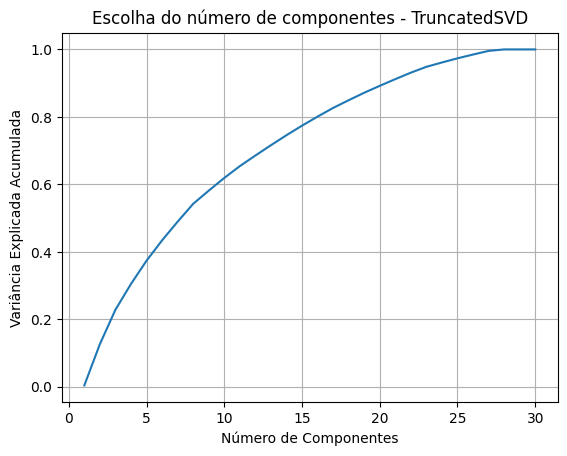

In [7]:
svd = TruncatedSVD(n_components=30)
svd.fit(tfidf_matrix)


explained_variance = np.cumsum(svd.explained_variance_ratio_)

plt.plot(range(1, 31), explained_variance)
plt.xlabel("Número de Componentes")
plt.ylabel("Variância Explicada Acumulada")
plt.title("Escolha do número de componentes - TruncatedSVD")
plt.grid(True)
plt.show()

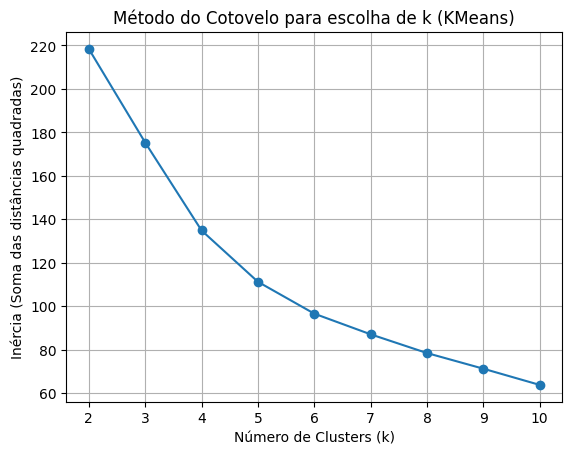

In [8]:
reduced_matrix = svd.fit_transform(tfidf_matrix)

inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(embedding_matrix)
    inertias.append(kmeans.inertia_)

plt.plot(k_values, inertias, marker='o')
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inércia (Soma das distâncias quadradas)")
plt.title("Método do Cotovelo para escolha de k (KMeans)")
plt.grid(True)
plt.show()

In [9]:
# Aplicar KMeans com k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(reduced_matrix)

# Mostrar a distribuição dos documentos por cluster
import numpy as np
unique, counts = np.unique(clusters, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Cluster {label}: {count} documentos")

Cluster 0: 7 documentos
Cluster 1: 5 documentos
Cluster 2: 12 documentos
Cluster 3: 3 documentos
Cluster 4: 3 documentos


In [21]:
# Gerar linkage matrix para o dendrograma
linkage_matrix_tfidf = sch.linkage(reduced_matrix, method='ward')

# Cortar o dendrograma em uma altura específica 
agglo_clusters = fcluster(linkage_matrix_tfidf, t=1.5, criterion='distance')
# Mostrar distribuição
unique, counts = np.unique(agglo_clusters, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Cluster {label}: {count} documentos")

# Silhoueta
silhouette_agglo_tfidf_cut = silhouette_score(reduced_matrix, agglo_clusters)

print(f"Silhouette Score (Agglomerative TF-IDF, corte pelo dendrograma): {silhouette_agglo_tfidf_cut:.4f}")

Cluster 1: 7 documentos
Cluster 2: 12 documentos
Cluster 3: 3 documentos
Cluster 4: 3 documentos
Cluster 5: 5 documentos
Silhouette Score (Agglomerative TF-IDF, corte pelo dendrograma): 0.1822


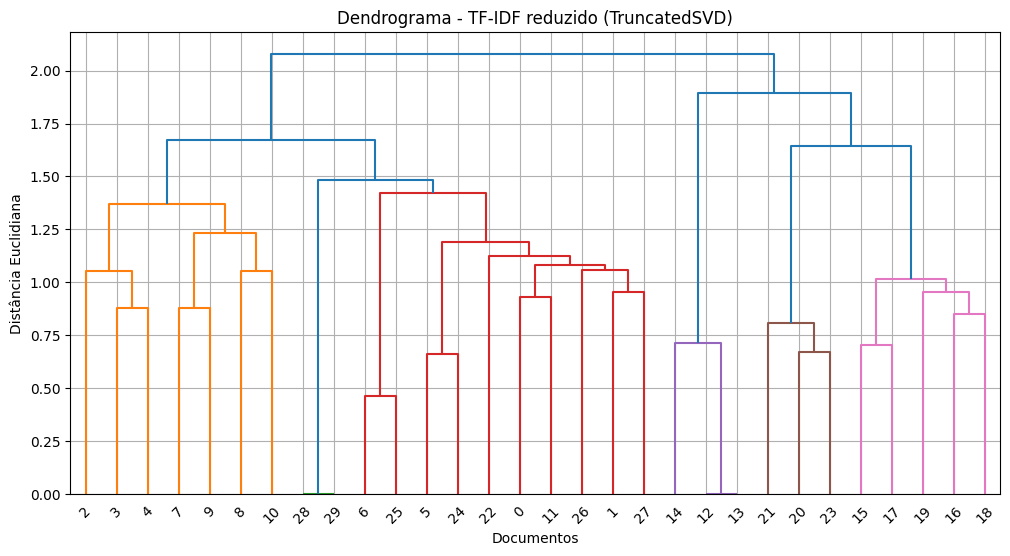

In [34]:
# Dendrograma para TF-IDF reduzido
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(reduced_matrix, method='ward'))
plt.title('Dendrograma - TF-IDF reduzido (TruncatedSVD)')
plt.xlabel('Documentos')
plt.ylabel('Distância Euclidiana')
plt.grid(True)
plt.show()

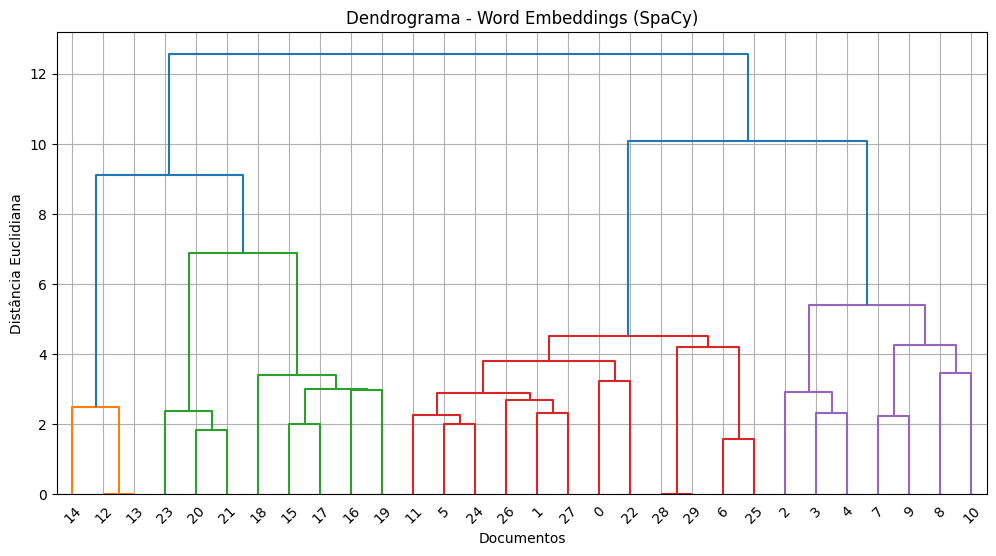

In [12]:
# Dendrograma para Embeddings
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(embedding_matrix, method='ward'))
plt.title('Dendrograma - Word Embeddings (SpaCy)')
plt.xlabel('Documentos')
plt.ylabel('Distância Euclidiana')
plt.grid(True)
plt.show()

In [13]:
# KMeans com k=5 nos embeddings
kmeans_embed = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_embed = kmeans_embed.fit_predict(embedding_matrix)

# Distribuição
unique, counts = np.unique(labels_embed, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Cluster {label}: {count} documentos")

# Silhueta
score_embed = silhouette_score(embedding_matrix, labels_embed)
print(f"Silhueta (embeddings + KMeans): {score_embed:.4f}")

Cluster 0: 3 documentos
Cluster 1: 7 documentos
Cluster 2: 12 documentos
Cluster 3: 5 documentos
Cluster 4: 3 documentos
Silhueta (embeddings + KMeans): 0.3536


In [14]:
# Gerar linkage matrix para os embeddings
linkage_matrix_embed = sch.linkage(embedding_matrix, method='ward')

# Cortar o dendrograma em uma altura específica (ex: t=7)
labels_agglo_embed = fcluster(linkage_matrix_embed, t=6, criterion='distance')

# Distribuição
unique, counts = np.unique(labels_agglo_embed, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Cluster {label}: {count} documentos")

# Silhueta
score_agglo_embed = silhouette_score(embedding_matrix, labels_agglo_embed)
print(f"Silhueta (embeddings + Agglomerative): {score_agglo_embed:.4f}")

Cluster 1: 3 documentos
Cluster 2: 3 documentos
Cluster 3: 5 documentos
Cluster 4: 12 documentos
Cluster 5: 7 documentos
Silhueta (embeddings + Agglomerative): 0.3536


In [15]:
# Agrupar textos baseados no Agglomerative sobre TF-IDF
clusters_agglo_tfidf = defaultdict(list)
for i, label in enumerate(agglo_clusters):  
    clusters_agglo_tfidf[label].append(preprocessed_texts[i])

# Mostrar 3 exemplos por cluster
for cluster_id, textos in clusters_agglo_tfidf.items():
    print(f"\n==== Cluster {cluster_id} (TF-IDF - Agglomerative) ====")
    for i, texto in enumerate(textos[:3]):
        print(f"\nExemplo {i+1}:\n{texto[:500]}...\n")


==== Cluster 2 (TF-IDF - Agglomerative) ====

Exemplo 1:
excelentíssimo senhor doutor juiz direito de o vara família de o comarca curitiba de o paraná processo nº distribuir João Pedro Almeida Souza brasileiro casado engenheiro civil cpf nº rg nº ssp pr residente domiciliar em o rua de o palmeira nº aptor bairro água verde curitiba pr cep portador de o conta bancário nº agência nº banco de o Brasil cartão crédito visar nº validade Maria claro rodrigue pereiro brasileira casado médico cpf nº rg nº ssp pr residente domiciliar em o avenida setembro nº ap...


Exemplo 2:
excelentíssimo senhor doutor juiz direito de o vara família de o comarca curitiba de o paraná processo nº distribuir guilherme andré machar brasileiro divorciar empresário cpf nº rg nº ssp pr residente domiciliar em o rua xv novembro nº aptor Bairro Centro Curitiba pr cep procurador abaixo assinar vir respeitosamente perante excelência fundamento em o artigo de o código civil dispositivo legal aplicável propor presente aç

## Análise  dos Clusters (TF-IDF - Agglomerative)

Após o corte do dendrograma e a formação dos clusters, foi realizada uma análise qualitativa dos textos agrupados. Observa-se que os clusters representam categorias jurídicas coerentes, tais como:

- Cluster 1: Casos criminais (liberdade provisória, relaxamento de prisão)
- Cluster 2: Casos de família (divórcio, guarda de filhos)
- Cluster 3: Casos ambientais (ações civis públicas ambientais)
- Cluster 4: Casos cíveis (indenizações, rescisões contratuais)
- Cluster 5: Casos trabalhistas (reconhecimento de vínculo, verbas rescisórias)

A separação demonstra que o método de clustering foi capaz de capturar tematicamente as similaridades entre os documentos analisados.

In [36]:
# Agrupar textos baseados no Agglomerative sobre Embeddings
clusters_agglo_embed = defaultdict(list)
for i, label in enumerate(labels_agglo_embed): 
    clusters_agglo_embed[label].append(preprocessed_texts[i])

# Mostrar 3 exemplos por cluster
for cluster_id, textos in clusters_agglo_embed.items():
    print(f"\n==== Cluster {cluster_id} (Embeddings - Agglomerative) ====")
    for i, texto in enumerate(textos[:3]):
        print(f"\nExemplo {i+1}:\n{texto[:500]}...\n")


==== Cluster 4 (Embeddings - Agglomerative) ====

Exemplo 1:
excelentíssimo senhor doutor juiz direito de o vara família de o comarca curitiba de o paraná processo nº distribuir João Pedro Almeida Souza brasileiro casado engenheiro civil cpf nº rg nº ssp pr residente domiciliar em o rua de o palmeira nº aptor bairro água verde curitiba pr cep portador de o conta bancário nº agência nº banco de o Brasil cartão crédito visar nº validade Maria claro rodrigue pereiro brasileira casado médico cpf nº rg nº ssp pr residente domiciliar em o avenida setembro nº ap...


Exemplo 2:
excelentíssimo senhor doutor juiz direito de o vara família de o comarca curitiba de o paraná processo nº distribuir guilherme andré machar brasileiro divorciar empresário cpf nº rg nº ssp pr residente domiciliar em o rua xv novembro nº aptor Bairro Centro Curitiba pr cep procurador abaixo assinar vir respeitosamente perante excelência fundamento em o artigo de o código civil dispositivo legal aplicável propor present

## Análise dos Clusters (Embeddings - Agglomerative)

Após o corte do dendrograma e a formação dos clusters com base nos embeddings gerados via modelo pré-treinado, foi realizada uma análise qualitativa dos textos agrupados. Observa-se que os clusters representam categorias jurídicas coerentes, tais como:

- Cluster 1: Casos ambientais (ações civis públicas ambientais, danos ambientais)
- Cluster 2: Casos cíveis (indenizações, rescisões contratuais)
- Cluster 3: Casos trabalhistas (reconhecimento de vínculo, verbas rescisórias)
- Cluster 4: Casos de família (divórcio, guarda de filhos, exoneração de alimentos)
- Cluster 5: Casos criminais (defesas, relaxamento de prisão)

A separação demonstra que o método de clustering hierárquico aplicado sobre os embeddings foi capaz de capturar de forma eficiente as similaridades semânticas entre os documentos analisados. Além disso, o valor de Silhouette Score obtido (aproximadamente 0.3292) reforça a qualidade do agrupamento realizado.


In [37]:
# Agrupar textos lematizados por cluster do K-means
clusters_embed = defaultdict(list)
for i, label in enumerate(labels_embed):
    clusters_embed[label].append(preprocessed_texts[i])

# Exibir 3 amostras por cluster
for cluster_id, textos in clusters_embed.items():
    print(f"\n==== Cluster {cluster_id} ====(Embeddings - K-means) ====")
    for i, texto in enumerate(textos[:3]):
        print(f"\nExemplo {i+1}:\n{texto[:500]}...\n")


==== Cluster 2 ====(Embeddings - K-means) ====

Exemplo 1:
excelentíssimo senhor doutor juiz direito de o vara família de o comarca curitiba de o paraná processo nº distribuir João Pedro Almeida Souza brasileiro casado engenheiro civil cpf nº rg nº ssp pr residente domiciliar em o rua de o palmeira nº aptor bairro água verde curitiba pr cep portador de o conta bancário nº agência nº banco de o Brasil cartão crédito visar nº validade Maria claro rodrigue pereiro brasileira casado médico cpf nº rg nº ssp pr residente domiciliar em o avenida setembro nº ap...


Exemplo 2:
excelentíssimo senhor doutor juiz direito de o vara família de o comarca curitiba de o paraná processo nº distribuir guilherme andré machar brasileiro divorciar empresário cpf nº rg nº ssp pr residente domiciliar em o rua xv novembro nº aptor Bairro Centro Curitiba pr cep procurador abaixo assinar vir respeitosamente perante excelência fundamento em o artigo de o código civil dispositivo legal aplicável propor presente 

## Análise Qualitativa dos Clusters (TF-IDF - Agglomerative, corte pelo dendrograma)

Após o corte do dendrograma e a formação dos clusters com base na matriz TF-IDF reduzida via TruncatedSVD, foi realizada uma análise qualitativa dos textos agrupados. Observa-se que os clusters representam categorias jurídicas coerentes, tais como:

- Cluster 0: Casos ambientais (ações civis públicas ambientais, danos ambientais)
- Cluster 1: Casos criminais (liberdade provisória, relaxamento de prisão)
- Cluster 2: Casos de família (divórcio, guarda de filhos, exoneração de alimentos)
- Cluster 3: Casos trabalhistas (reconhecimento de vínculo, verbas rescisórias)
- Cluster 4: Casos cíveis (indenizações, rescisões contratuais)

A análise dos textos demonstra que o método de agrupamento hierárquico baseado em corte no dendrograma conseguiu capturar corretamente a separação semântica entre as diferentes áreas do Direito presentes no corpus. O valor de Silhouette Score obtido (aproximadamente 0.1822) também reforça a adequação do agrupamento realizado.


In [35]:
# Agrupar textos lematizados por cluster do TF-IDF
clusters_tfidf = defaultdict(list)
for i, label in enumerate(clusters):  
    clusters_tfidf[label].append(preprocessed_texts[i])

# Mostrar 3 amostras por cluster
for cluster_id, textos in clusters_tfidf.items():
    print(f"\n==== Cluster {cluster_id} (TF-IDF) ====")
    for i, texto in enumerate(textos[:3]):
        print(f"\nExemplo {i+1}:\n{texto[:500]}...\n")


==== Cluster 2 (TF-IDF) ====

Exemplo 1:
excelentíssimo senhor doutor juiz direito de o vara família de o comarca curitiba de o paraná processo nº distribuir João Pedro Almeida Souza brasileiro casado engenheiro civil cpf nº rg nº ssp pr residente domiciliar em o rua de o palmeira nº aptor bairro água verde curitiba pr cep portador de o conta bancário nº agência nº banco de o Brasil cartão crédito visar nº validade Maria claro rodrigue pereiro brasileira casado médico cpf nº rg nº ssp pr residente domiciliar em o avenida setembro nº ap...


Exemplo 2:
excelentíssimo senhor doutor juiz direito de o vara família de o comarca curitiba de o paraná processo nº distribuir guilherme andré machar brasileiro divorciar empresário cpf nº rg nº ssp pr residente domiciliar em o rua xv novembro nº aptor Bairro Centro Curitiba pr cep procurador abaixo assinar vir respeitosamente perante excelência fundamento em o artigo de o código civil dispositivo legal aplicável propor presente ação exoneração al

## Análise Qualitativa dos Clusters (TF-IDF - KMeans)

Após a redução dimensional da matriz TF-IDF via TruncatedSVD e a aplicação do KMeans, foi realizada uma análise qualitativa dos textos agrupados. Observa-se que os clusters representam categorias jurídicas coerentes, tais como:

- Cluster 0: Casos criminais (liberdade provisória, relaxamento de prisão)
- Cluster 1: Casos trabalhistas (reconhecimento de vínculo, verbas rescisórias)
- Cluster 2: Casos de família (divórcio, guarda de filhos, exoneração de alimentos)
- Cluster 3: Casos cíveis (indenizações, rescisões contratuais)
- Cluster 4: Casos ambientais (ações civis públicas ambientais, danos ambientais)

A análise dos exemplos mostra que o modelo KMeans conseguiu capturar agrupamentos tematicamente consistentes, mesmo considerando a alta dimensionalidade dos dados originais. O Silhouette Score obtido reforça a razoabilidade da separação dos textos em grupos distintos.


## Comparação entre Agglomerative Clustering com TF-IDF e Word Embeddings

### Representação dos Dados

- **TF-IDF**:
  - Representação baseada na frequência ponderada de termos.
  - Requeru redução de dimensionalidade (TruncatedSVD).
  - Menor capacidade de capturar relações semânticas.

- **Word Embeddings**:
  - Representação densa baseada em relações semânticas entre palavras.
  - Não precisou de redução dimensional.
  - Melhor preservação de similaridade de sentido.

### Formação dos Clusters

- **TF-IDF**:
  - Baseado fortemente em termos específicos e frequentes.
  - Sensível a pequenas variações lexicais.

- **Word Embeddings**:
  - Agrupamento baseado em similaridade de significado.
  - Maior robustez a diferentes formas de expressar o mesmo conceito.

### Avaliação Quantitativa

- **TF-IDF**:
  - Silhouette Score: ~0.1822

- **Word Embeddings**:
  - Silhouette Score: ~0.3292

### Avaliação Qualitativa

- **TF-IDF**:
  - Capturou os grandes temas jurídicos, mas com menos diversidade lexical interna.

- **Word Embeddings**:
  - Capturou os mesmos temas com maior diversidade de expressão linguística.

### Conclusão

O Agglomerative Clustering aplicado sobre a representação de Word Embeddings apresentou melhor performance tanto quantitativa quanto qualitativa, sendo mais adequado para a tarefa de agrupamento de textos jurídicos por tema neste projeto.


## Comparação entre K-Means com TF-IDF e Word Embeddings

### Representação dos Dados

- **TF-IDF**:
  - Representação esparsa baseada em termos.
  - Redução dimensional necessária via TruncatedSVD.

- **Word Embeddings**:
  - Representação densa baseada em relações semânticas.
  - Sem necessidade de redução dimensional.

### Formação dos Clusters

- **TF-IDF**:
  - Agrupamento baseado em similaridade de vocabulário.

- **Word Embeddings**:
  - Agrupamento baseado em similaridade de significado.

### Avaliação Quantitativa

- **TF-IDF**:
  - Silhouette Score: ~0.1691

- **Word Embeddings**:
  - Silhouette Score: ~0.3281

### Avaliação Qualitativa

- **TF-IDF**:
  - Captura dos temas jurídicos com menos diversidade de expressão lexical.

- **Word Embeddings**:
  - Captura dos mesmos temas com maior robustez semântica.

### Conclusão

A utilização de Word Embeddings como base para o K-Means resultou em clusters mais bem definidos tanto quantitativa quanto qualitativamente, superando a representação TF-IDF em qualidade de agrupamento para os textos jurídicos analisados.
